# Robustness testing with known ground truth

When SynForecast injects an anomaly, changepoint, or gap, it also keeps the label and the uncorrupted series. That lets you measure two things you normally can't: how well a detector finds the corruptions, and how much they cost a forecaster. Both need answers that real data doesn't hand you.

:::{.callout-tip}
## Why synthetic data

A detector's precision and recall are only defined if you know which points are anomalies. Measuring the cost of contamination needs a clean copy of the same series. On real data you have neither; here both come for free.
:::

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from synforecast.exogenous import ExogenousConfig
from synforecast.generators import SeasonalGenerator


def robust_zscores(y: np.ndarray, window: int = 25) -> np.ndarray:
    """Rolling robust z-score: |y - median| / (1.4826 * MAD) in a window."""
    n = len(y)
    z = np.zeros(n)
    half = window // 2
    for i in range(n):
        lo, hi = max(0, i - half), min(n, i + half + 1)
        w = y[lo:hi]
        med = np.median(w)
        mad = np.median(np.abs(w - med))
        scale = 1.4826 * mad if mad > 1e-9 else (np.std(w) + 1e-9)
        z[i] = abs(y[i] - med) / scale
    return z

## Detecting anomalies

We make weekly-seasonal series with 4% of points hit by spikes and dips, and record their positions with `ExogenousConfig(anomaly_flags=True)`. A rolling robust z-score scores each point; varying the threshold moves along the precision/recall trade-off.

In [ ]:
FLAGS = ExogenousConfig(anomaly_flags=True)

panel = SeasonalGenerator(
    engine='polars', min_length=400, max_length=400, freq='D',
    seasonality_period=7, seasonality_amplitude=8.0, base_level=100.0,
    noise_level=2.0,
    anomalies=True, anomaly_fraction=0.04, anomaly_types=['spike', 'dip'],
    spike_magnitude=30.0, dip_magnitude=-30.0,
    exogenous=FLAGS, seed=7,
).generate(n_series=25)

# Pool robust z-scores and ground-truth labels across every series.
scores, labels = [], []
for uid in panel['unique_id'].unique(maintain_order=True):
    s = panel.filter(pl.col('unique_id') == uid)
    scores.append(robust_zscores(s['y'].to_numpy()))
    labels.append(s['anomaly_flag'].to_numpy())
scores = np.concatenate(scores)
labels = np.concatenate(labels).astype(bool)
print(f'{labels.sum()} injected anomalies across {len(labels)} points '
      f'({labels.mean():.1%})')

400 injected anomalies across 10000 points (4.0%)


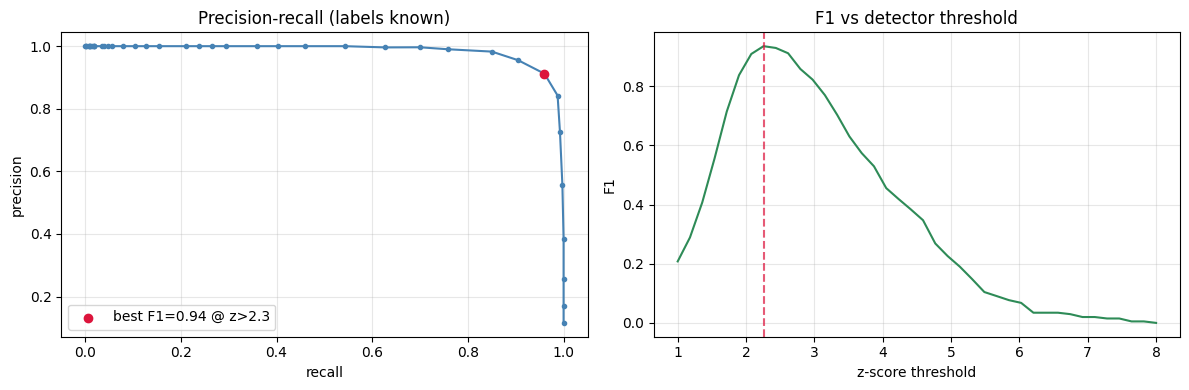

In [ ]:
thresholds = np.linspace(1.0, 8.0, 40)
precision, recall, f1 = [], [], []
for t in thresholds:
    pred = scores > t
    tp = int((pred & labels).sum())
    fp = int((pred & ~labels).sum())
    fn = int((~pred & labels).sum())
    p = tp / (tp + fp) if tp + fp else 1.0
    r = tp / (tp + fn) if tp + fn else 0.0
    precision.append(p)
    recall.append(r)
    f1.append(2 * p * r / (p + r) if p + r else 0.0)

best = int(np.argmax(f1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(recall, precision, marker='.', color='steelblue')
ax1.scatter([recall[best]], [precision[best]], color='crimson', zorder=5,
            label=f'best F1={f1[best]:.2f} @ z>{thresholds[best]:.1f}')
ax1.set(xlabel='recall', ylabel='precision', title='Precision-recall (labels known)')
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(thresholds, f1, color='seagreen')
ax2.axvline(thresholds[best], color='crimson', ls='--', alpha=0.7)
ax2.set(xlabel='z-score threshold', ylabel='F1', title='F1 vs detector threshold')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The labels make the operating point measurable rather than assumed: the marked threshold is the one with the best F1. Higher thresholds buy precision at the cost of recall. Substitute your own detector to see where it sits on the same axes.

## The cost of contamination

We generate clean seasonal series, hold out the last 14 days, then corrupt a growing fraction of the *training* history and refit a trend-plus-seasonal-means model. That model reads its slope and seasonal profile off every training point, so outliers shift the fit — a seasonal-naive rule, which only repeats recent values, would barely register them.

:::{.callout-warning}
## Scale against the clean series

Each forecast is scaled by an in-sample seasonal error taken from the **clean** training series and held fixed across contamination levels. Scale by the contaminated series instead and the spikes inflate the denominator, so error appears to *drop* as you add noise — a real trap, not a hypothetical one.
:::

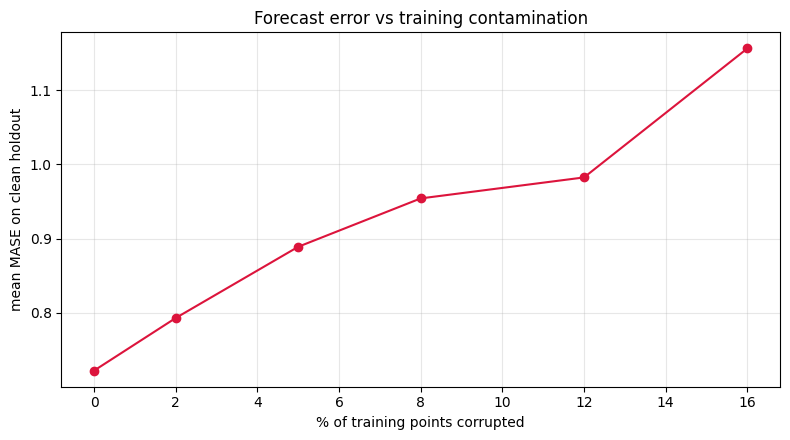

MASE at 0% / 16% contamination: 0.722 / 1.157


In [ ]:
H, SEASON = 14, 7
clean = SeasonalGenerator(
    engine='polars', min_length=200, max_length=200, freq='D',
    seasonality_period=SEASON, seasonality_amplitude=8.0, base_level=100.0,
    noise_level=2.0, seed=11,
).generate(n_series=40)

rng = np.random.default_rng(0)
series = [clean.filter(pl.col('unique_id') == u)['y'].to_numpy()
          for u in clean['unique_id'].unique(maintain_order=True)]


def trend_seasonal_forecast(train, h, season):
    """Least-squares trend + per-position seasonal means (outlier-sensitive)."""
    n = len(train)
    t = np.arange(n)
    slope, intercept = np.polyfit(t, train, 1)
    resid = train - (slope * t + intercept)
    seasonal = np.array([resid[k::season].mean() for k in range(season)])
    fut = np.arange(n, n + h)
    return slope * fut + intercept + seasonal[fut % season]


levels = [0.0, 0.02, 0.05, 0.08, 0.12, 0.16]
curve = []
for c in levels:
    errs = []
    for y in series:
        train, test = y[:-H].copy(), y[-H:]
        # Fixed scale from the CLEAN training series — never contaminated.
        denom = np.mean(np.abs(train[SEASON:] - train[:-SEASON])) + 1e-9
        k = int(round(c * len(train)))
        if k:
            idx = rng.choice(len(train), size=k, replace=False)
            train[idx] += rng.choice([-1, 1], size=k) * rng.uniform(15, 35, size=k)
        fc = trend_seasonal_forecast(train, H, SEASON)
        errs.append(np.mean(np.abs(test - fc)) / denom)
    curve.append(float(np.mean(errs)))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([c * 100 for c in levels], curve, marker='o', color='crimson')
ax.set(xlabel='% of training points corrupted', ylabel='mean MASE on clean holdout',
       title='Forecast error vs training contamination')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('MASE at 0% / 16% contamination: '
      f'{curve[0]:.3f} / {curve[-1]:.3f}')

Error rises with contamination, measured on a holdout we know is clean and against a scale the noise can't move. The same setup works for any pipeline: perturb the input by a known amount and watch a trustworthy metric respond.

:::{.callout-note}
## Related capabilities

- [Anomalies](anomalies), [changepoints](changepoints), and [missingness](missingness) — the injection knobs used here, each with a ground-truth flag column.
- [When does synthetic data help?](when_synthetic_helps) — the accuracy picture, and where synthetic data pays off beyond it.
:::